# 🚗 CarDD Dataset → YOLOv8 Training Pipeline

**End-to-end notebook:** dataset validation → COCO→YOLO conversion → augmentation → training → evaluation

| | |
|---|---|
| **Input** | `data/CarDD_release/` |
| **Output** | `CarDD-outputs/` |
| **Platform** | Lightning AI Studio |

### Expected Input Structure
```
data/CarDD_release/
├── CarDD_COCO/
│   ├── annotations/   (instances_*.json)
│   ├── train2017/
│   ├── val2017/
│   └── test2017/
└── CarDD_SOD/
    ├── CarDD-TR/
    ├── CarDD-VAL/
    └── CarDD-TE/
```

### Output Structure
```
CarDD-outputs/
├── yolo_dataset/
│   ├── images/{train,val,test}/
│   ├── labels/{train,val,test}/
│   └── cardd.yaml
├── visualizations/
│   ├── class_distribution.png
│   ├── sample_boxes.png
│   ├── class_weights.png
│   └── sod_samples.png
└── class_weights.json
```

---
## ⚙️ Cell 1 — Install Dependencies

In [1]:
!pip install ultralytics albumentations matplotlib seaborn tqdm pillow -q

---
## 📦 Cell 2 — Imports & Global Config

In [2]:
import os, json, random, shutil, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import albumentations as A

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths — edit DATA_ROOT if your folder is elsewhere ──────
DATA_ROOT = Path("/teamspace/studios/this_studio/data/CarDD_release")
COCO_ROOT = DATA_ROOT / "CarDD_COCO"
SOD_ROOT  = DATA_ROOT / "CarDD_SOD"

OUT_ROOT  = Path("/teamspace/studios/this_studio/CarDD-outputs")
YOLO_ROOT = OUT_ROOT / "yolo_dataset"
VIZ_DIR   = OUT_ROOT / "visualizations"

# ── YOLO image size ──────────────────────────────────────────
IMG_SIZE = 640

# ── CarDD damage categories (COCO annotation order) ─────────
CANONICAL_CATS = {
    "dent":          0,
    "scratch":       1,
    "crack":         2,
    "glass shatter": 3,
    "tire flat":     4,
    "lamp broken":   5,
}
PALETTE = ["#e63946", "#2a9d8f", "#e9c46a", "#f4a261", "#264653", "#a8dadc"]

print("✅ Imports and config loaded.")
print(f"   DATA_ROOT : {DATA_ROOT}")
print(f"   OUT_ROOT  : {OUT_ROOT}")

✅ Imports and config loaded.
   DATA_ROOT : /teamspace/studios/this_studio/data/CarDD_release
   OUT_ROOT  : /teamspace/studios/this_studio/CarDD-outputs


---
## ✅ Cell 3 — Step 1: Validate Input Directory Structure

In [3]:
def validate_structure():
    """
    Checks that the expected folders exist before running anything.
    Prints a clear ✅ / ❌ report so you can spot missing pieces fast.
    """
    print("\n" + "═"*60)
    print("  STEP 1 — Validating input directory structure")
    print("═"*60)

    checks = {
        "CarDD_COCO/annotations" : COCO_ROOT / "annotations",
        "CarDD_COCO/train2017"   : COCO_ROOT / "train2017",
        "CarDD_COCO/val2017"     : COCO_ROOT / "val2017",
        "CarDD_COCO/test2017"    : COCO_ROOT / "test2017",
        "CarDD_SOD/CarDD-TR"     : SOD_ROOT  / "CarDD-TR",
        "CarDD_SOD/CarDD-VAL"    : SOD_ROOT  / "CarDD-VAL",
        "CarDD_SOD/CarDD-TE"     : SOD_ROOT  / "CarDD-TE",
    }

    all_ok = True
    for label, path in checks.items():
        exists = path.exists()
        status = "✅" if exists else "❌  MISSING"
        print(f"   {status}  {label}")
        if not exists:
            all_ok = False

    if not all_ok:
        raise FileNotFoundError(
            "\n\n❌  Some folders are missing. "
            "Make sure DATA_ROOT points to your 'data/CarDD_release' folder.\n"
            f"   Currently set to: {DATA_ROOT.resolve()}\n"
        )

    print("\n   ✅  All folders found!\n")


validate_structure()


════════════════════════════════════════════════════════════
  STEP 1 — Validating input directory structure
════════════════════════════════════════════════════════════
   ✅  CarDD_COCO/annotations
   ✅  CarDD_COCO/train2017
   ✅  CarDD_COCO/val2017
   ✅  CarDD_COCO/test2017
   ✅  CarDD_SOD/CarDD-TR
   ✅  CarDD_SOD/CarDD-VAL
   ✅  CarDD_SOD/CarDD-TE

   ✅  All folders found!



---
## 📁 Cell 4 — Step 2: Create Output Directories

In [4]:
def create_output_dirs():
    print("═"*60)
    print("  STEP 2 — Creating output directories")
    print("═"*60)

    for split in ["train", "val", "test"]:
        (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)
    VIZ_DIR.mkdir(parents=True, exist_ok=True)

    print(f"   ✅  Output root    : {OUT_ROOT.resolve()}")
    print(f"   ✅  YOLO dataset   : {YOLO_ROOT.resolve()}")
    print(f"   ✅  Visualizations : {VIZ_DIR.resolve()}\n")


create_output_dirs()

════════════════════════════════════════════════════════════
  STEP 2 — Creating output directories
════════════════════════════════════════════════════════════
   ✅  Output root    : /teamspace/studios/this_studio/CarDD-outputs
   ✅  YOLO dataset   : /teamspace/studios/this_studio/CarDD-outputs/yolo_dataset
   ✅  Visualizations : /teamspace/studios/this_studio/CarDD-outputs/visualizations



---
## 🔍 Cell 5 — Steps 3–4: Helper Functions (COCO Parser + YOLO Converter)

> **COCO bbox format:** `[x_min, y_min, width, height]` (absolute pixels)  
> **YOLO bbox format:** `[cx, cy, nw, nh]` (normalized 0–1)

In [5]:
def load_coco_annotation(json_path: Path):
    """
    Loads a COCO-format JSON and returns:
      cat_map : {coco_category_id → (class_idx, class_name)}
      img_map : {image_id → {filename, width, height}}
      ann_map : {image_id → [annotation_dicts]}
    """
    with open(json_path) as f:
        data = json.load(f)

    cat_map = {}
    for i, cat in enumerate(data["categories"]):
        name    = cat["name"].lower().strip()
        cls_idx = CANONICAL_CATS.get(name, i)
        cat_map[cat["id"]] = (cls_idx, name)

    img_map = {}
    for img in data["images"]:
        img_map[img["id"]] = {
            "filename": img["file_name"],
            "width":    img["width"],
            "height":   img["height"],
        }

    ann_map = defaultdict(list)
    for ann in data["annotations"]:
        ann_map[ann["image_id"]].append(ann)

    return cat_map, img_map, ann_map


def coco_to_yolo(bbox, img_w, img_h):
    """
    Convert COCO absolute bbox to YOLO normalized format.
    Clamps to [0, 1] to avoid edge-overflow artifacts.
    """
    x, y, bw, bh = bbox
    cx = (x + bw / 2) / img_w
    cy = (y + bh / 2) / img_h
    nw = bw / img_w
    nh = bh / img_h
    cx = min(max(cx, 0.0), 1.0)
    cy = min(max(cy, 0.0), 1.0)
    nw = min(max(nw, 0.0), 1.0)
    nh = min(max(nh, 0.0), 1.0)
    return cx, cy, nw, nh


print("✅ COCO parser and YOLO converter defined.")

✅ COCO parser and YOLO converter defined.


---
## 🔄 Cell 6 — Step 5: Augmentation Transforms

| Transform | Why |
|---|---|
| `HorizontalFlip` | Damage is spatially symmetric on cars |
| `RandomBrightnessContrast` | Varied lighting & weather conditions |
| `Blur` | Simulates phone-camera focus issues |
| `ShiftScaleRotate` | Scale & position invariance |
| `Resize(640)` | YOLO standard input size |

In [6]:
def get_train_transform():
    """Training augmentation — applied ONLY to the train split."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2,
                                   contrast_limit=0.2, p=0.5),
        A.Blur(blur_limit=3, p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=10, border_mode=0, p=0.4),
        A.Resize(IMG_SIZE, IMG_SIZE),
    ], bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.3,  # drop boxes that mostly leave the frame
    ))


def get_val_transform():
    """Val/test: only resize. No randomness — fair, reproducible evaluation."""
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
    ], bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
    ))


print("✅ Augmentation transforms defined.")

✅ Augmentation transforms defined.


---
## 🏗️ Cell 7 — Step 6: Process One Split (COCO → YOLO on disk)

In [7]:
def process_coco_split(split_name: str,
                        img_folder: Path,
                        ann_json:   Path,
                        transform,
                        label_counts: dict):
    """
    Reads every image + annotation for one split, converts to YOLO format,
    applies the transform, and writes resized JPGs + .txt label files.
    """
    print(f"\n   Processing '{split_name}' split ...")
    print(f"   Annotations : {ann_json}")
    print(f"   Images      : {img_folder}")

    if not ann_json.exists():
        print(f"   ⚠️  Annotation file not found, skipping: {ann_json}")
        return

    cat_map, img_map, ann_map = load_coco_annotation(ann_json)

    skipped = 0
    saved   = 0

    for img_id, img_info in tqdm(img_map.items(), desc=f"  [{split_name}]"):
        img_path = img_folder / img_info["filename"]
        if not img_path.exists():
            skipped += 1
            continue

        anns = ann_map.get(img_id, [])
        if not anns:
            skipped += 1
            continue

        try:
            img_pil = Image.open(img_path).convert("RGB")
            img_np  = np.array(img_pil)
        except Exception:
            skipped += 1
            continue

        h, w = img_np.shape[:2]

        bboxes_yolo  = []
        class_labels = []

        for ann in anns:
            cat_id = ann["category_id"]
            if cat_id not in cat_map:
                continue
            cls_idx, cls_name = cat_map[cat_id]
            cx, cy, nw, nh = coco_to_yolo(ann["bbox"], w, h)
            if nw < 0.001 or nh < 0.001:
                continue   # skip degenerate boxes
            bboxes_yolo.append([cx, cy, nw, nh])
            class_labels.append(cls_idx)
            label_counts[cls_idx] = label_counts.get(cls_idx, 0) + 1

        if not bboxes_yolo:
            skipped += 1
            continue

        try:
            out = transform(image=img_np,
                            bboxes=bboxes_yolo,
                            class_labels=class_labels)
        except Exception:
            skipped += 1
            continue

        out_img    = out["image"]
        out_boxes  = out["bboxes"]
        out_labels = out["class_labels"]

        if not out_boxes:
            skipped += 1
            continue

        stem             = img_path.stem
        out_img_path     = YOLO_ROOT / "images" / split_name / f"{stem}.jpg"
        Image.fromarray(out_img).save(out_img_path, quality=95)

        out_lbl_path = YOLO_ROOT / "labels" / split_name / f"{stem}.txt"
        with open(out_lbl_path, "w") as f:
            for (cx, cy, nw, nh), cls_id in zip(out_boxes, out_labels):
                f.write(f"{int(cls_id)} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

        saved += 1

    print(f"   ✅  Saved: {saved}  |  Skipped: {skipped}")
    return saved


print("✅ process_coco_split() defined.")

✅ process_coco_split() defined.


---
## ▶️ Cell 8 — Run COCO → YOLO Conversion for All Splits

In [8]:
print("\n" + "═"*60)
print("  STEP 3-6 — Converting COCO annotations → YOLO format")
print("═"*60)

ann_dir = COCO_ROOT / "annotations"

def find_ann(candidates):
    for name in candidates:
        p = ann_dir / name
        if p.exists():
            return p
    return None

train_ann = find_ann(["instances_train2017.json", "train.json"])
val_ann   = find_ann(["instances_val2017.json",   "val.json"])
test_ann  = find_ann(["instances_test2017.json",  "test.json"])

# Fallback: pick any JSON containing the split name
all_jsons = sorted(ann_dir.glob("*.json"))
if train_ann is None and len(all_jsons) >= 1:
    train_ann = all_jsons[0]
if val_ann   is None and len(all_jsons) >= 2:
    val_ann   = all_jsons[1]
if test_ann  is None and len(all_jsons) >= 3:
    test_ann  = all_jsons[2]

print(f"\n   Annotation files found:")
print(f"     train → {train_ann}")
print(f"     val   → {val_ann}")
print(f"     test  → {test_ann}")

# Load cat_map from train annotation (used later for YAML)
cat_map = {}
if train_ann and train_ann.exists():
    with open(train_ann) as f:
        d = json.load(f)
    for i, cat in enumerate(d["categories"]):
        name    = cat["name"].lower().strip()
        cls_idx = CANONICAL_CATS.get(name, i)
        cat_map[cat["id"]] = (cls_idx, name)

label_counts: dict = {}

splits = [
    ("train", COCO_ROOT/"train2017", train_ann, get_train_transform()),
    ("val",   COCO_ROOT/"val2017",   val_ann,   get_val_transform()),
    ("test",  COCO_ROOT/"test2017",  test_ann,  get_val_transform()),
]

for split_name, img_folder, ann_json, transform in splits:
    if ann_json and ann_json.exists():
        process_coco_split(split_name, img_folder, ann_json, transform, label_counts)
    else:
        print(f"\n   ⚠️  Skipping '{split_name}' — annotation JSON not found")

print("\n✅ All splits converted.")


════════════════════════════════════════════════════════════
  STEP 3-6 — Converting COCO annotations → YOLO format
════════════════════════════════════════════════════════════

   Annotation files found:
     train → /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
     val   → /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_val2017.json
     test  → /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_test2017.json


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



   Processing 'train' split ...
   Annotations : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
   Images      : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/train2017


  [train]: 100%|██████████| 2816/2816 [01:10<00:00, 40.05it/s]


   ✅  Saved: 2816  |  Skipped: 0

   Processing 'val' split ...
   Annotations : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_val2017.json
   Images      : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/val2017


  [val]: 100%|██████████| 810/810 [00:17<00:00, 45.33it/s]


   ✅  Saved: 810  |  Skipped: 0

   Processing 'test' split ...
   Annotations : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/annotations/instances_test2017.json
   Images      : /teamspace/studios/this_studio/data/CarDD_release/CarDD_COCO/test2017


  [test]: 100%|██████████| 374/374 [00:08<00:00, 45.69it/s]

   ✅  Saved: 374  |  Skipped: 0

✅ All splits converted.


---
## 📄 Cell 9 — Step 7: Write `cardd.yaml`

In [9]:
def write_yaml(cat_map: dict):
    """
    Ultralytics YOLO reads a YAML specifying:
      path, train/val/test image folders, nc (num classes), and names.
    """
    id2name = {cls_idx: name for _, (cls_idx, name) in cat_map.items()}
    num_cls = max(id2name.keys()) + 1
    names   = [id2name.get(i, f"class_{i}") for i in range(num_cls)]

    yaml_lines = [
        "# CarDD — Car Damage Detection",
        "# Generated by CarDD_YOLO_Pipeline.ipynb",
        "",
        f"path: {YOLO_ROOT.resolve()}",
        "train: images/train",
        "val:   images/val",
        "test:  images/test",
        "",
        f"nc: {num_cls}",
        "names:",
    ]
    for i, name in enumerate(names):
        yaml_lines.append(f"  {i}: {name}")

    yaml_path = YOLO_ROOT / "cardd.yaml"
    yaml_path.write_text("\n".join(yaml_lines) + "\n")
    print(f"   📄 YAML saved → {yaml_path}")
    return yaml_path, num_cls, names


print("═"*60)
print("  STEP 7 — Writing cardd.yaml")
print("═"*60)

yaml_path, num_cls, names = write_yaml(cat_map)

════════════════════════════════════════════════════════════
  STEP 7 — Writing cardd.yaml
════════════════════════════════════════════════════════════
   📄 YAML saved → /teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/cardd.yaml


---
## ⚖️ Cell 10 — Step 8: Class Imbalance → Inverse-Frequency Weights

**Formula:** `weight_i = total_instances / (num_classes × count_i)`

- Rare classes (e.g. *tire flat*) → **HIGH** weight → model pays more attention  
- Common classes (e.g. *dent*) → **LOW** weight → prevents over-fitting

In [10]:
def compute_class_weights(label_counts: dict, num_cls: int) -> dict:
    total = sum(label_counts.values())
    weights = {}
    for cls_id in range(num_cls):
        count = label_counts.get(cls_id, 1)  # avoid division by zero
        weights[cls_id] = round(total / (num_cls * count), 4)
    return weights


print("═"*60)
print("  STEP 8 — Class Imbalance → Weights")
print("═"*60)

weights = compute_class_weights(label_counts, num_cls)

weights_path = OUT_ROOT / "class_weights.json"
with open(weights_path, "w") as f:
    json.dump({names[k]: v for k, v in weights.items()}, f, indent=2)
print(f"   ✅  Weights saved → {weights_path}")

print(f"\n   {'Class':<18} {'Instances':>10}  {'Weight':>8}")
print(f"   {'-'*40}")
for i in range(num_cls):
    print(f"   {names[i]:<18} {label_counts.get(i,0):>10}  {weights.get(i,1.0):>8.3f}")
print(f"   {'─'*40}")
print(f"   {'TOTAL':<18} {sum(label_counts.values()):>10}")

════════════════════════════════════════════════════════════
  STEP 8 — Class Imbalance → Weights
════════════════════════════════════════════════════════════
   ✅  Weights saved → /teamspace/studios/this_studio/CarDD-outputs/class_weights.json

   Class               Instances    Weight
   ----------------------------------------
   dent                     2543     0.573
   scratch                  3595     0.405
   crack                     898     1.622
   glass shatter             681     2.139
   tire flat                 319     4.566
   lamp broken               704     2.069
   ────────────────────────────────────────
   TOTAL                    8740


---
## 📊 Cell 11 — Step 9a: Visualize Class Distribution

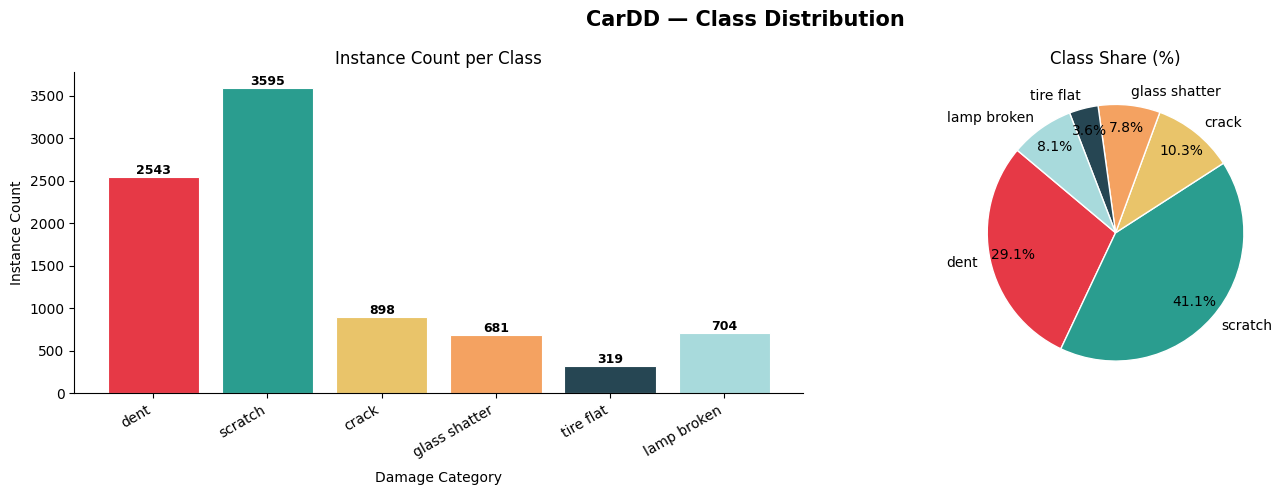

   📊 class_distribution.png saved → /teamspace/studios/this_studio/CarDD-outputs/visualizations/class_distribution.png


In [11]:
def viz_class_distribution(label_counts: dict, names: list):
    counts = [label_counts.get(i, 0) for i in range(len(names))]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("CarDD — Class Distribution", fontsize=15, fontweight="bold")

    colors = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

    # Bar chart
    ax = axes[0]
    bars = ax.bar(names, counts, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("Damage Category", labelpad=8)
    ax.set_ylabel("Instance Count")
    ax.set_title("Instance Count per Class")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts)*0.01,
                str(cnt), ha="center", fontsize=9, fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.spines[["top", "right"]].set_visible(False)

    # Pie chart
    ax2 = axes[1]
    ax2.pie(counts, labels=names, colors=colors,
            autopct="%1.1f%%", startangle=140,
            pctdistance=0.82, wedgeprops=dict(edgecolor="white", linewidth=1))
    ax2.set_title("Class Share (%)")

    plt.tight_layout()
    out = VIZ_DIR / "class_distribution.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   📊 class_distribution.png saved → {out}")


viz_class_distribution(label_counts, names)

---
## 🖼️ Cell 12 — Step 9b: Visualize Sample Bounding Boxes

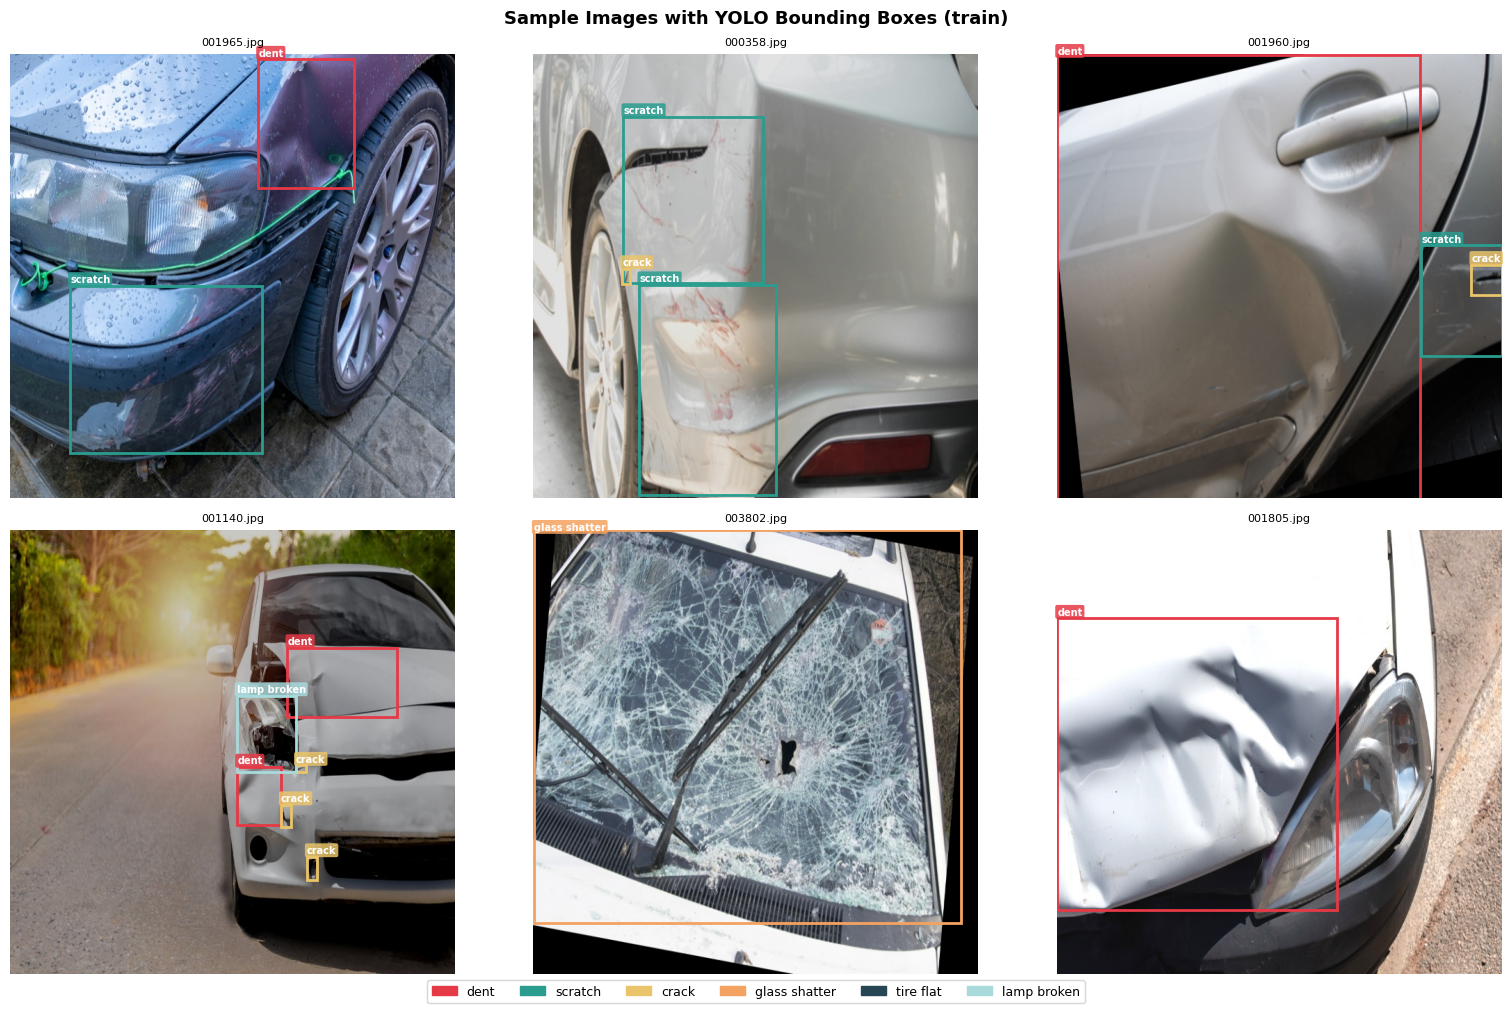

   🖼️  sample_boxes.png saved → /teamspace/studios/this_studio/CarDD-outputs/visualizations/sample_boxes.png


In [12]:
def viz_sample_boxes(img_folder: Path, lbl_folder: Path,
                     names: list, split="train", n=6):
    """Draws YOLO bounding boxes on saved images to verify the conversion."""
    img_paths = list((img_folder / split).glob("*.jpg"))
    if not img_paths:
        print(f"   ⚠️  No images found in {img_folder/split}")
        return

    sample_paths = random.sample(img_paths, min(n, len(img_paths)))
    ncols = 3
    nrows = math.ceil(len(sample_paths) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
    fig.suptitle(f"Sample Images with YOLO Bounding Boxes ({split})",
                 fontsize=13, fontweight="bold")
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes, sample_paths):
        img_np = np.array(Image.open(img_path))
        h, w   = img_np.shape[:2]
        ax.imshow(img_np)

        lbl_path = lbl_folder / split / (img_path.stem + ".txt")
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id = int(float(parts[0]))
                    cx, cy, nw, nh = map(float, parts[1:])
                    bw = nw * w;  bh = nh * h
                    bx = (cx - nw/2) * w;  by = (cy - nh/2) * h
                    color = PALETTE[cls_id % len(PALETTE)]
                    rect  = mpatches.FancyBboxPatch(
                        (bx, by), bw, bh,
                        boxstyle="square,pad=0",
                        linewidth=2, edgecolor=color, facecolor="none")
                    ax.add_patch(rect)
                    label = names[cls_id] if cls_id < len(names) else str(cls_id)
                    ax.text(bx, max(by - 5, 0), label,
                            color="white", fontsize=7, fontweight="bold",
                            bbox=dict(facecolor=color, alpha=0.85, pad=1,
                                      linewidth=0, boxstyle="round,pad=0.2"))
        ax.axis("off")
        ax.set_title(img_path.name[:30], fontsize=8)

    for ax in axes[len(sample_paths):]:
        ax.axis("off")

    handles = [mpatches.Patch(color=PALETTE[i % len(PALETTE)], label=names[i])
               for i in range(len(names))]
    fig.legend(handles=handles, loc="lower center", ncol=len(names),
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    out = VIZ_DIR / "sample_boxes.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   🖼️  sample_boxes.png saved → {out}")


viz_sample_boxes(YOLO_ROOT/"images", YOLO_ROOT/"labels", names, split="train")

---
## ⚖️ Cell 13 — Step 9c: Visualize Class Weights

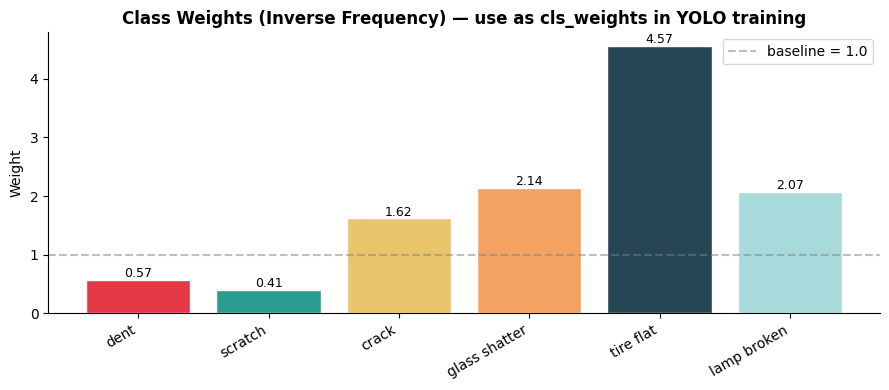

   ⚖️  class_weights.png saved → /teamspace/studios/this_studio/CarDD-outputs/visualizations/class_weights.png


In [13]:
def viz_class_weights(weights: dict, names: list):
    wvals  = [weights.get(i, 1.0) for i in range(len(names))]
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(names, wvals, color=colors, edgecolor="white")
    ax.set_title("Class Weights (Inverse Frequency) — use as cls_weights in YOLO training",
                 fontweight="bold")
    ax.set_ylabel("Weight")
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="baseline = 1.0")
    ax.legend()
    for bar, wv in zip(bars, wvals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(wvals)*0.01,
                f"{wv:.2f}", ha="center", fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    out = VIZ_DIR / "class_weights.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"   ⚖️  class_weights.png saved → {out}")


viz_class_weights(weights, names)

---
## 🗺️ Cell 14 — Step 9d: Visualize SOD Samples (Image | Mask | Edge)

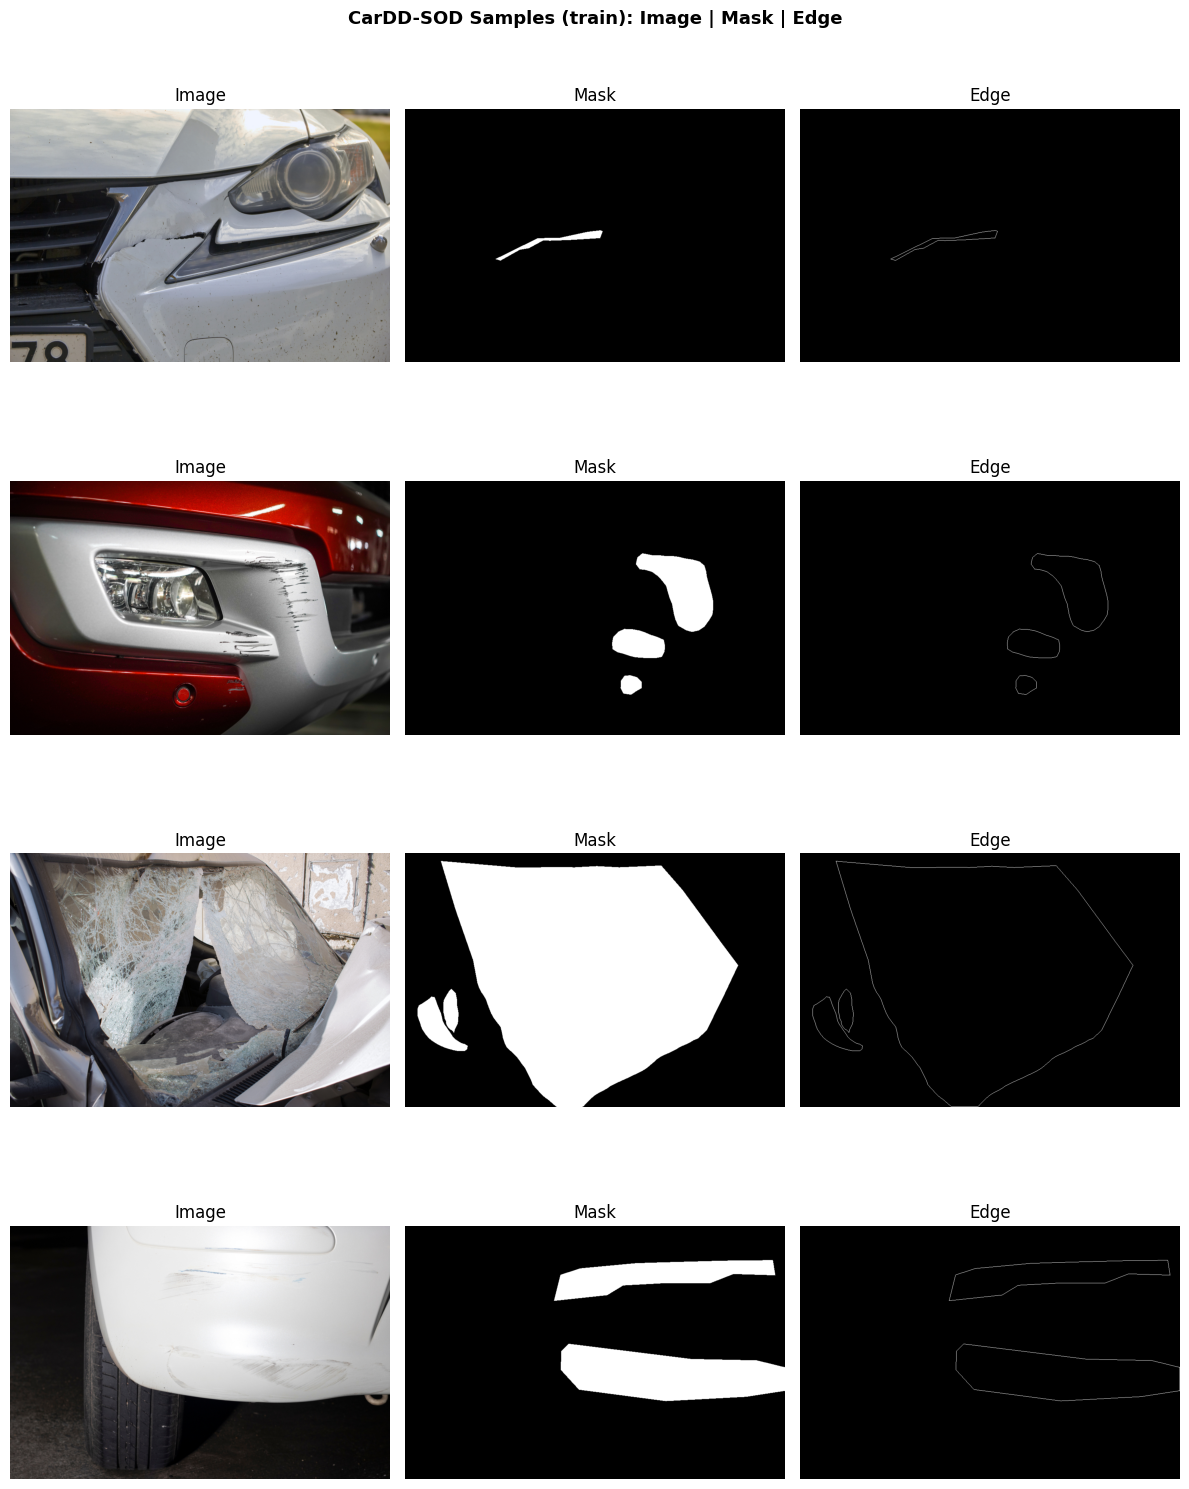

   🗺️  sod_samples.png saved → /teamspace/studios/this_studio/CarDD-outputs/visualizations/sod_samples.png


In [14]:
def viz_sod_samples(n=6):
    """Shows SOD branch samples: original image, binary mask, and edge map."""
    img_dir  = SOD_ROOT / "CarDD-TR" / "CarDD-TR-Image"
    mask_dir = SOD_ROOT / "CarDD-TR" / "CarDD-TR-Mask"
    edge_dir = SOD_ROOT / "CarDD-TR" / "CarDD-TR-Edge"

    imgs = list(img_dir.glob("*")) if img_dir.exists() else []
    if not imgs:
        print("   ⚠️  No SOD images found, skipping.")
        return

    sample_imgs = random.sample(imgs, min(n, len(imgs)))
    fig, axes   = plt.subplots(len(sample_imgs), 3,
                               figsize=(12, 4*len(sample_imgs)))
    fig.suptitle("CarDD-SOD Samples (train): Image | Mask | Edge",
                 fontsize=13, fontweight="bold")

    if len(sample_imgs) == 1:
        axes = [axes]

    def load_any(folder, stem):
        for ext in [".png", ".jpg", ".jpeg", ".bmp"]:
            p = folder / (stem + ext)
            if p.exists():
                return np.array(Image.open(p).convert("L"))
        return None

    for row_axes, img_path in zip(axes, sample_imgs):
        stem    = img_path.stem
        img_np  = np.array(Image.open(img_path).convert("RGB"))
        mask_np = load_any(mask_dir, stem)
        edge_np = load_any(edge_dir, stem)

        row_axes[0].imshow(img_np);  row_axes[0].set_title("Image")
        if mask_np is not None:
            row_axes[1].imshow(mask_np, cmap="gray")
        else:
            row_axes[1].text(0.5, 0.5, "No mask", ha="center")
        row_axes[1].set_title("Mask")
        if edge_np is not None:
            row_axes[2].imshow(edge_np, cmap="gray")
        else:
            row_axes[2].text(0.5, 0.5, "No edge", ha="center")
        row_axes[2].set_title("Edge")
        for ax in row_axes:
            ax.axis("off")

    plt.tight_layout()
    out = VIZ_DIR / "sod_samples.png"
    plt.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"   🗺️  sod_samples.png saved → {out}")


viz_sod_samples(n=4)

---
## 🚀 Cell 15 — Train Baseline Model: YOLOv8n

**YOLOv8n (nano)** — fast to train, good for establishing a performance baseline.

In [15]:
from ultralytics import YOLO

YAML_PATH = str(YOLO_ROOT / "cardd.yaml")

model1 = YOLO("yolov8n.pt")

results1 = model1.train(
    data            = YAML_PATH,
    epochs          = 100,
    imgsz           = IMG_SIZE,
    batch           = 16,
    device          = 0,
    mosaic          = 1.0,
    mixup           = 0.1,
    label_smoothing = 0.1,
    patience        = 30,
    optimizer       = "AdamW",
    lr0             = 0.001,
    project         = "/teamspace/studios/this_studio/CarDD-outputs/runs",
    name            = "yolov8n_baseline",
    exist_ok        = True,
)

metrics1 = model1.val(
    data  = YAML_PATH,
    split = "test",
)

print("\n=== BASELINE (YOLOv8n) RESULTS ===")
print(f"mAP@0.5      : {metrics1.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics1.box.map:.4f}")

New https://pypi.org/project/ultralytics/8.4.42 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/cardd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask

---
## 🚀 Cell 16 — Train Novel Model: YOLOv8m

**YOLOv8m (medium)** — larger backbone, stronger augmentation (`copy_paste`, `perspective`), lower learning rate for better convergence.

In [16]:
model2 = YOLO("yolov8m.pt")

results2 = model2.train(
    data            = YAML_PATH,
    epochs          = 100,
    imgsz           = IMG_SIZE,
    batch           = 8,
    device          = 0,
    mosaic          = 1.0,
    mixup           = 0.15,
    copy_paste      = 0.1,
    label_smoothing = 0.1,
    degrees         = 10.0,
    perspective     = 0.001,
    patience        = 30,
    optimizer       = "AdamW",
    lr0             = 0.0005,
    project         = "/teamspace/studios/this_studio/CarDD-outputs/runs",
    name            = "yolov8m_novel",
    exist_ok        = True,
)

metrics2 = model2.val(
    data  = YAML_PATH,
    split = "test",
)

print("\n=== NOVEL MODEL (YOLOv8m) RESULTS ===")
print(f"mAP@0.5      : {metrics2.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics2.box.map:.4f}")

New https://pypi.org/project/ultralytics/8.4.42 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/cardd.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mas

---
## 📊 Cell 17 — Compare Models: Baseline vs Novel

Loads the best saved weights from both runs and evaluates on the test split.

In [17]:
RUNS_DIR = Path("/teamspace/studios/this_studio/CarDD-outputs/runs")

m1_weights = RUNS_DIR / "yolov8n_baseline" / "weights" / "best.pt"
m2_weights = RUNS_DIR / "yolov8m_novel"    / "weights" / "best.pt"

if not m1_weights.exists() or not m2_weights.exists():
    print("⚠️  One or both weight files not found. Run Cells 15 & 16 first.")
else:
    model_b = YOLO(str(m1_weights))
    model_n = YOLO(str(m2_weights))

    m1 = model_b.val(data=YAML_PATH, split="test")
    m2 = model_n.val(data=YAML_PATH, split="test")

    print(f"\n{'Model':<25} {'mAP@0.5':>10} {'mAP@0.5:0.95':>14}")
    print("-" * 52)
    print(f"{'YOLOv8n (baseline)':<25} {m1.box.map50:>10.4f} {m1.box.map:>14.4f}")
    print(f"{'YOLOv8m (novel)':<25} {m2.box.map50:>10.4f} {m2.box.map:>14.4f}")
    print(f"{'Improvement':<25} {m2.box.map50-m1.box.map50:>+10.4f} {m2.box.map-m1.box.map:>+14.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1520.7±570.8 MB/s, size: 105.9 KB)
val: Scanning /teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/labels/test.cache... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 142.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.1it/s 3.4s<0.1s
                   all        374        785      0.684      0.689      0.689      0.523
                  dent        157        236      0.583      0.617      0.582      0.322
               scratch        183        307      0.502      0.589      0.536      0.282
                 crack         48         70      0.491      0.373      0.365      0.196
         glass shatter         71         71      0.911      0.958      0.979      0.883
  

---
## 📈 Cell 18 — Plot Training Curves (Loss & mAP)

Reads the `results.csv` files Ultralytics saves automatically.

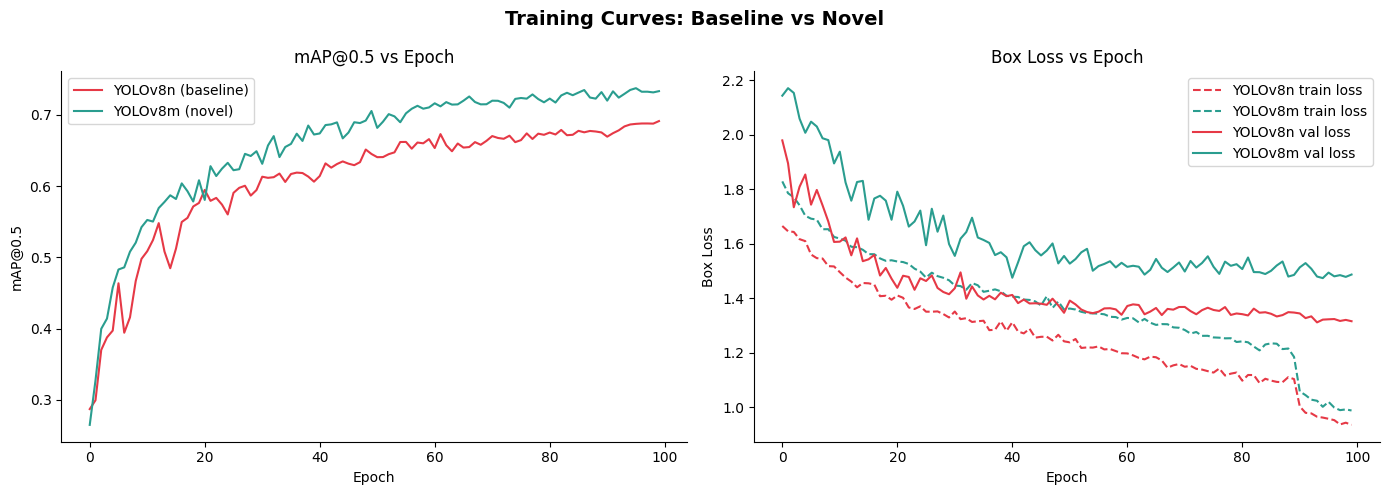

   📈 training_curves.png saved → /teamspace/studios/this_studio/CarDD-outputs/visualizations/training_curves.png


In [18]:
import pandas as pd

baseline_csv = RUNS_DIR / "yolov8n_baseline" / "results.csv"
novel_csv    = RUNS_DIR / "yolov8m_novel"    / "results.csv"

if not baseline_csv.exists() or not novel_csv.exists():
    print("⚠️  results.csv not found. Run training cells first.")
else:
    df1 = pd.read_csv(baseline_csv)
    df2 = pd.read_csv(novel_csv)
    df1.columns = df1.columns.str.strip()
    df2.columns = df2.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves: Baseline vs Novel", fontsize=14, fontweight="bold")

    # mAP@0.5
    ax = axes[0]
    ax.plot(df1["metrics/mAP50(B)"], label="YOLOv8n (baseline)", color="#e63946")
    ax.plot(df2["metrics/mAP50(B)"], label="YOLOv8m (novel)",    color="#2a9d8f")
    ax.set_title("mAP@0.5 vs Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP@0.5")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    # Box loss
    ax2 = axes[1]
    ax2.plot(df1["train/box_loss"], label="YOLOv8n train loss", color="#e63946", linestyle="--")
    ax2.plot(df2["train/box_loss"], label="YOLOv8m train loss", color="#2a9d8f", linestyle="--")
    ax2.plot(df1["val/box_loss"],   label="YOLOv8n val loss",   color="#e63946")
    ax2.plot(df2["val/box_loss"],   label="YOLOv8m val loss",   color="#2a9d8f")
    ax2.set_title("Box Loss vs Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Box Loss")
    ax2.legend()
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out = VIZ_DIR / "training_curves.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   📈 training_curves.png saved → {out}")

---
## 🏁 Cell 19 — Final Summary

In [19]:
print("\n" + "═"*60)
print("  FINAL SUMMARY")
print("═"*60)

print(f"\n  {'Class':<18} {'Instances':>10}  {'Weight':>8}")
print(f"  {'-'*40}")
for i in range(num_cls):
    print(f"  {names[i]:<18} {label_counts.get(i,0):>10}  {weights.get(i,1.0):>8.3f}")
print(f"  {'─'*40}")
print(f"  {'TOTAL':<18} {sum(label_counts.values()):>10}")

print(f"""
  📁 Output structure:
     CarDD-outputs/
     ├── yolo_dataset/
     │   ├── images/{{train,val,test}}/    ← {IMG_SIZE}×{IMG_SIZE} JPGs
     │   ├── labels/{{train,val,test}}/    ← YOLO .txt files
     │   └── cardd.yaml
     ├── visualizations/
     │   ├── class_distribution.png
     │   ├── sample_boxes.png
     │   ├── class_weights.png
     │   ├── sod_samples.png
     │   └── training_curves.png
     ├── class_weights.json
     └── runs/
         ├── yolov8n_baseline/weights/best.pt
         └── yolov8m_novel/weights/best.pt

  ✅  Pipeline complete!
""")


════════════════════════════════════════════════════════════
  FINAL SUMMARY
════════════════════════════════════════════════════════════

  Class               Instances    Weight
  ----------------------------------------
  dent                     2543     0.573
  scratch                  3595     0.405
  crack                     898     1.622
  glass shatter             681     2.139
  tire flat                 319     4.566
  lamp broken               704     2.069
  ────────────────────────────────────────
  TOTAL                    8740

  📁 Output structure:
     CarDD-outputs/
     ├── yolo_dataset/
     │   ├── images/{train,val,test}/    ← 640×640 JPGs
     │   ├── labels/{train,val,test}/    ← YOLO .txt files
     │   └── cardd.yaml
     ├── visualizations/
     │   ├── class_distribution.png
     │   ├── sample_boxes.png
     │   ├── class_weights.png
     │   ├── sod_samples.png
     │   └── training_curves.png
     ├── class_weights.json
     └── runs/
         ├── yol